In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
base_path = "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405"

ataxia = pd.read_csv(f"{base_path}/ataxia_avg_arm_analysis_summary.csv")
pd_data = pd.read_csv(f"{base_path}/pd_avg_arm_analysis_summary.csv")

In [3]:
ataxia.head()

,subject,trial_num,test_type,cycle_asym_directional,cycle_variability,reach_asym_directional,swing_freq_asym_directional,swing_freq_variability,lat_exc_asym_directional,lat_exc_variability,...,vel_avg_mean,vel_avg_variability,rms_avg_mean,rms_avg_variability,reach_avg_peak,lat_exc_avg_peak,amp_avg_peak,vel_avg_peak,peak_acc_avg_peak,rms_acc_avg_peak
0,101,1,NG,-8.259294,0.452117,-35.517260,8.259294,0.082593,-41.474790,1.626406,...,0.065906,0.521920,1.552845,0.479999,0.195434,0.254724,0.033629,0.168563,6.817902,3.214395
1,101,1,RG,0.490744,0.482159,-18.076507,-0.490744,0.004907,-19.396508,1.500132,...,0.053059,0.469464,1.263745,0.444379,0.202553,0.235420,0.037030,0.122580,7.514536,2.667201
2,101,2,NG,-17.224742,0.473866,-49.196891,17.224742,0.172247,-53.391239,1.775613,...,0.076360,0.354974,1.701424,0.321921,0.213280,0.280643,0.032594,0.153963,6.859592,3.066151
3,101,2,RG,0.064010,0.412780,-25.898036,-0.064010,0.000640,-32.610029,1.416621,...,0.059198,0.407080,1.347017,0.361130,0.178256,0.182525,0.028809,0.127745,6.398395,2.455916
4,109,1,NG,0.139741,0.317559,3.004392,-0.139741,0.001397,1.348863,1.291999,...,0.205860,0.486681,3.285147,0.346815,0.442911,0.511660,0.127705,0.424580,16.959147,5.634655


In [5]:
pd_data.head()

,subject,trial_num,test_type,cycle_asym_directional,cycle_variability,reach_asym_directional,swing_freq_asym_directional,swing_freq_variability,lat_exc_asym_directional,lat_exc_variability,...,vel_avg_mean,vel_avg_variability,rms_avg_mean,rms_avg_variability,reach_avg_peak,lat_exc_avg_peak,amp_avg_peak,vel_avg_peak,peak_acc_avg_peak,rms_acc_avg_peak
0,102,1,NG,1.344461,0.356798,-5.280449,-1.344461,0.013445,4.189252,0.803579,...,0.180415,0.515320,2.556179,0.401068,0.396915,0.368809,0.087609,0.357775,8.961654,4.158488
1,102,1,RG,-3.213428,0.292143,0.384970,3.213428,0.032134,17.979777,0.921922,...,0.155122,0.635800,2.106449,0.527920,0.239954,0.275474,0.056087,0.344270,9.496009,4.422011
2,102,2,NG,1.636072,0.267051,-13.048686,-1.636072,0.016361,1.165194,1.012158,...,0.279475,0.430983,3.286013,0.341936,0.431013,0.410819,0.106007,0.494919,11.804627,5.426319
3,102,2,RG,-2.733948,0.287321,5.781423,2.733948,0.027339,10.353021,1.217450,...,0.185756,0.639415,2.083438,0.424136,0.291781,0.328875,0.089528,0.404431,7.777764,3.446242
4,103,1,NG,3.132621,0.402918,6.053243,-3.132621,0.031326,26.150896,1.264987,...,0.139006,0.454050,2.283449,0.369759,0.288402,0.381088,0.053280,0.253883,8.927600,3.849318


In [6]:
ataxia["diagnosis"] = 1   # Ataxia
pd_data["diagnosis"] = 0   # PD

In [7]:
df = pd.concat([ataxia, pd_data], ignore_index=True)

In [ ]:
df = df.dropna() 

In [10]:
print(df.columns)

Index(['subject', 'trial_num', 'test_type', 'cycle_asym_directional',
       'cycle_variability', 'reach_asym_directional',
       'swing_freq_asym_directional', 'swing_freq_variability',
       'lat_exc_asym_directional', 'lat_exc_variability',
       'amp_asym_directional', 'vel_asym_directional',
       'rms_acc_asym_directional', 'reach_peak_asym_directional',
       'lat_exc_peak_asym_directional', 'amp_peak_asym_directional',
       'vel_peak_asym_directional', 'peak_acc_peak_asym_directional',
       'rms_acc_peak_asym_directional', 'avg_cycles_n', 'avg_avg_cycle',
       'reach_avg_mean', 'reach_avg_variability', 'swing_freq_avg',
       'lat_exc_avg_mean', 'lat_exc_avg_variability', 'amp_avg_mean',
       'amp_avg_variability', 'vel_avg_mean', 'vel_avg_variability',
       'rms_avg_mean', 'rms_avg_variability', 'reach_avg_peak',
       'lat_exc_avg_peak', 'amp_avg_peak', 'vel_avg_peak', 'peak_acc_avg_peak',
       'rms_acc_avg_peak', 'diagnosis'],
      dtype='object')


In [12]:
X = df.drop(columns=["diagnosis", "subject", "trial_num"])
y = df["diagnosis"]
groups = df["subject"]

In [13]:
categorical_features = ["test_type"]

numeric_features = [col for col in X.columns if col != "test_type"]

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

In [16]:
LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=2000
)

clf = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

In [18]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [19]:
clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.88      0.93      0.90        40

    accuracy                           0.86        57
   macro avg       0.84      0.82      0.83        57
weighted avg       0.86      0.86      0.86        57

AUC: 0.7897058823529413


In [21]:
import numpy as np
import pandas as pd

ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(["test_type"])

feature_names = np.concatenate([cat_features, numeric_features])

coefs = clf.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
}).sort_values("abs_coefficient", ascending=False)

print(importance.head(15))

                           feature  coefficient  abs_coefficient
22                lat_exc_avg_mean    -2.156731         2.156731
31                lat_exc_avg_peak     1.562394         1.562394
26                    vel_avg_mean    -1.258413         1.258413
35                rms_acc_avg_peak     0.805750         0.805750
32                    amp_avg_peak     0.769747         0.769747
30                  reach_avg_peak     0.762813         0.762813
27             vel_avg_variability    -0.740431         0.740431
23         lat_exc_avg_variability    -0.678704         0.678704
2                cycle_variability    -0.653654         0.653654
34               peak_acc_avg_peak     0.489825         0.489825
15  peak_acc_peak_asym_directional    -0.481040         0.481040
16   rms_acc_peak_asym_directional     0.449447         0.449447
18                   avg_avg_cycle    -0.314753         0.314753
14       vel_peak_asym_directional    -0.262511         0.262511
6         lat_exc_asym_di

In [22]:
importance

,feature,coefficient,abs_coefficient
22,lat_exc_avg_mean,-2.156731,2.156731
31,lat_exc_avg_peak,1.562394,1.562394
26,vel_avg_mean,-1.258413,1.258413
35,rms_acc_avg_peak,0.805750,0.805750
32,amp_avg_peak,0.769747,0.769747
30,reach_avg_peak,0.762813,0.762813
27,vel_avg_variability,-0.740431,0.740431
23,lat_exc_avg_variability,-0.678704,0.678704
2,cycle_variability,-0.653654,0.653654
34,peak_acc_avg_peak,0.489825,0.489825


In [23]:
from sklearn.model_selection import GroupKFold, cross_val_score

cv = GroupKFold(n_splits=5)

auc_scores = cross_val_score(
    clf,
    X,
    y,
    groups=df["subject"],
    cv=cv,
    scoring="roc_auc"
)

print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())

AUC mean: 0.8045620107017166
AUC std: 0.07590044113585277


In [24]:
feature_groups = {
    "lat_exc": ["lat_exc_avg_mean", "lat_exc_avg_peak", "lat_exc_variability", "lat_exc_asym_directional"],
    "velocity": ["vel_avg_mean", "vel_avg_variability", "vel_peak_asym_directional"],
    "amplitude": ["amp_avg_mean", "amp_avg_peak", "amp_asym_directional"],
    "cycle": ["cycle_variability", "avg_avg_cycle"],
    "acceleration": ["rms_acc_avg_peak", "peak_acc_avg_peak", "rms_acc_peak_asym_directional"]
}

In [25]:
group_importance = {}

for group, feats in feature_groups.items():
    group_importance[group] = importance[
        importance["feature"].isin(feats)
    ]["abs_coefficient"].mean()

print(group_importance)

{'lat_exc': np.float64(0.9904061204563762), 'velocity': np.float64(0.7537853261528502), 'amplitude': np.float64(0.27300107053569816), 'cycle': np.float64(0.4842036849433742), 'acceleration': np.float64(0.5816739286461575)}


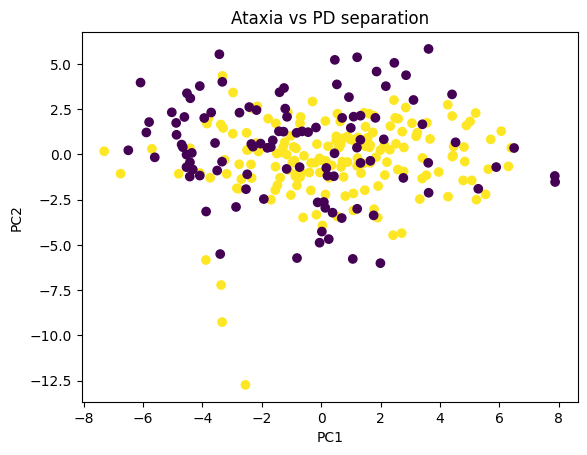

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = clf.named_steps["preprocess"].fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Ataxia vs PD separation")
plt.show()

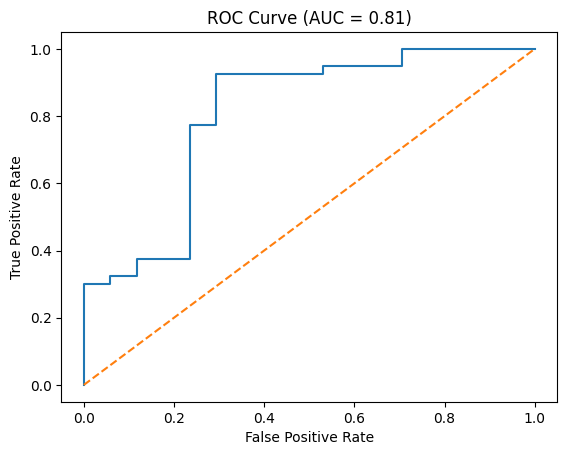

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

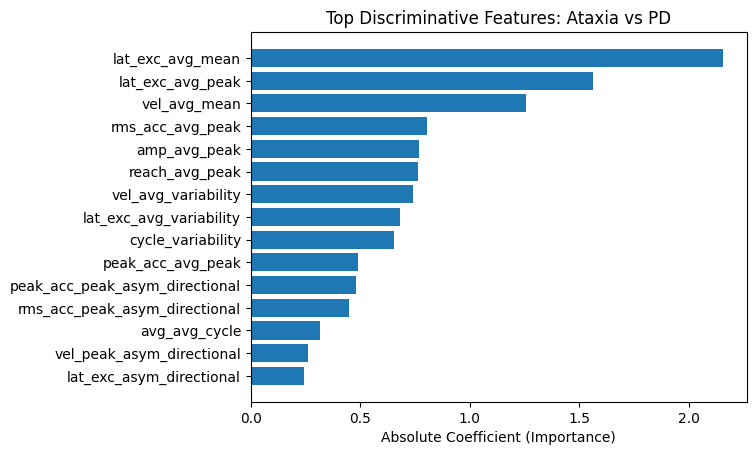

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

top_feats = importance.sort_values("abs_coefficient", ascending=False).head(15)

plt.barh(top_feats["feature"][::-1], top_feats["abs_coefficient"][::-1])
plt.xlabel("Absolute Coefficient (Importance)")
plt.title("Top Discriminative Features: Ataxia vs PD")
plt.show()

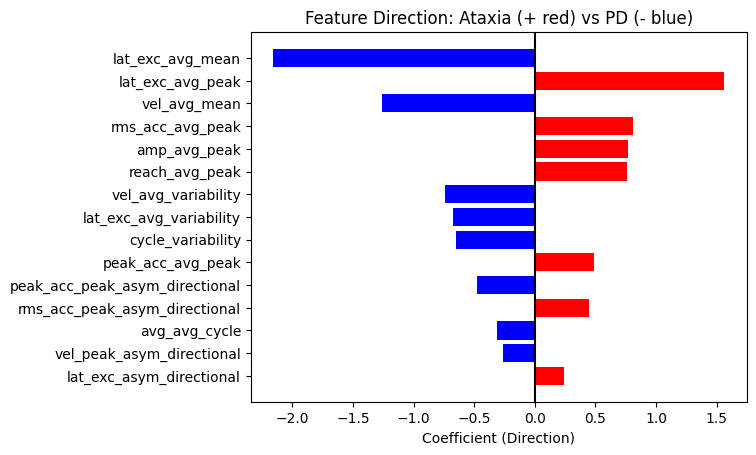

In [30]:
top_feats = importance.sort_values("abs_coefficient", ascending=False).head(15)

# reverse for nicer top-to-bottom ordering
features = top_feats["feature"][::-1]
coefs = top_feats["coefficient"][::-1]

colors = ["red" if c > 0 else "blue" for c in coefs]

plt.barh(features, coefs, color=colors)
plt.axvline(0, color="black")
plt.xlabel("Coefficient (Direction)")
plt.title("Feature Direction: Ataxia (+ red) vs PD (- blue)")
plt.show()

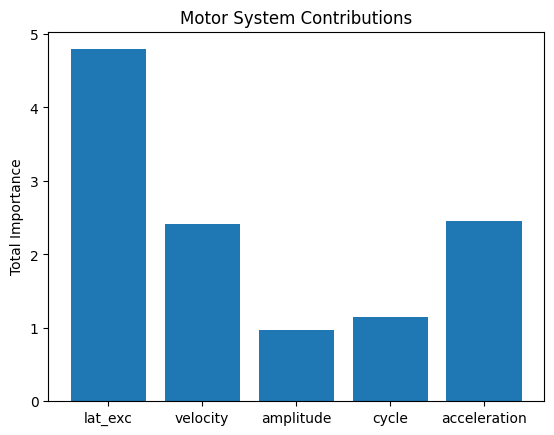

In [32]:
group_scores = {
    "lat_exc": 0,
    "velocity": 0,
    "amplitude": 0,
    "cycle": 0,
    "acceleration": 0
}

for f, coef in zip(importance["feature"], importance["abs_coefficient"]):
    if "lat_exc" in f:
        group_scores["lat_exc"] += coef
    elif "vel" in f:
        group_scores["velocity"] += coef
    elif "amp" in f:
        group_scores["amplitude"] += coef
    elif "cycle" in f:
        group_scores["cycle"] += coef
    elif "acc" in f:
        group_scores["acceleration"] += coef

plt.bar(group_scores.keys(), group_scores.values())
plt.ylabel("Total Importance")
plt.title("Motor System Contributions")
plt.show()

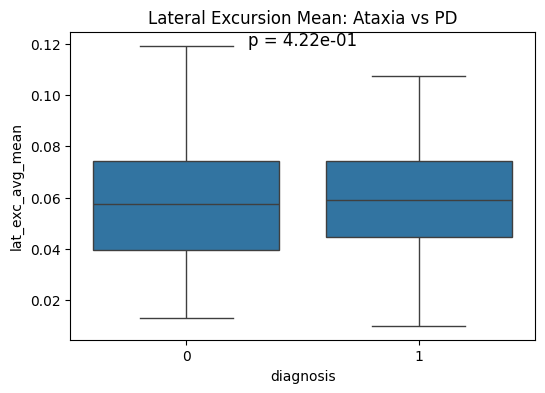

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

ataxia_vals = df[df["diagnosis"] == 1]["lat_exc_avg_mean"]
pd_vals = df[df["diagnosis"] == 0]["lat_exc_avg_mean"]

stat, p = mannwhitneyu(ataxia_vals, pd_vals)

plt.figure(figsize=(6,4))
ax = sns.boxplot(data=df, x="diagnosis", y="lat_exc_avg_mean")

# annotation position
y_max = df["lat_exc_avg_mean"].max()

ax.text(
    0.5, y_max,
    f"p = {p:.2e}",
    ha="center",
    fontsize=12
)

plt.title("Lateral Excursion Mean: Ataxia vs PD")
plt.show()